In [14]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [15]:
PROC = Path(r"D:\yield_curve_forecast\data\processed")

yield_col   = ["DGS3MO", "DGS1", "DGS2", "DGS5", "DGS10", "DGS30"]
maturities  = np.array([0.25, 1, 2, 5, 10, 30])      # in YEARS, aligned to yield_col

Y = pd.read_parquet(PROC / "yield_curve_data.parquet").set_index("observation_date")[yield_col]
Y = Y.dropna()
Y.index.freq = "MS"

TEST_SIZE = 60
split      = len(Y) - TEST_SIZE
test_dates = Y.index[split:]

print(f"Sample : {Y.index[0].date()} -> {Y.index[-1].date()}  ({len(Y)} months)")
print(f"Test   : {test_dates[0].date()} -> {test_dates[-1].date()}  ({TEST_SIZE} months)")

Sample : 1992-01-01 -> 2025-09-01  (405 months)
Test   : 2020-10-01 -> 2025-09-01  (60 months)


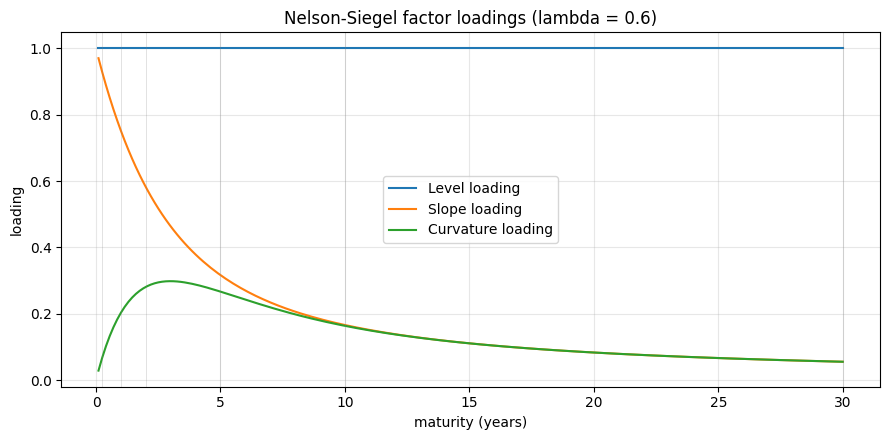

In [16]:
LAMBDA = 0.60   # fixed; places the curvature hump ~2-3Y (Diebold-Li-style simplification)

#Returns the 3 Nelson-Siegel factor loadings for a vector of maturities tau.
def ns_loadings(tau, lam=LAMBDA):
    slope = (1 - np.exp(-lam * tau)) / (lam * tau)
    curv  = slope - np.exp(-lam * tau)
    level = np.ones_like(tau)
    return np.column_stack([level, slope, curv])   # shape (n_maturities, 3)

DESIGN = ns_loadings(maturities)     #the fixed 6x3 loading matrix, reused every month

grid = np.linspace(0.1, 30, 200)
Lg = ns_loadings(grid)
plt.figure(figsize=(9,4.5))
for j, name in enumerate(["Level loading", "Slope loading", "Curvature loading"]):
    plt.plot(grid, Lg[:, j], label=name)
for t in maturities:
    plt.axvline(t, color="grey", lw=0.4, alpha=0.4)
plt.title(f"Nelson-Siegel factor loadings (lambda = {LAMBDA})")
plt.xlabel("maturity (years)"); plt.ylabel("loading"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In-sample curve reconstruction RMSE (3 factors -> 6 yields): 0.0794

Factor summary:
      Level   Slope  Curvature
mean 4.7030 -2.1420    -1.8020
std  1.6050  1.8120     2.1840
min  1.2550 -5.3280    -6.7800
max  8.4080  2.2290     4.4280


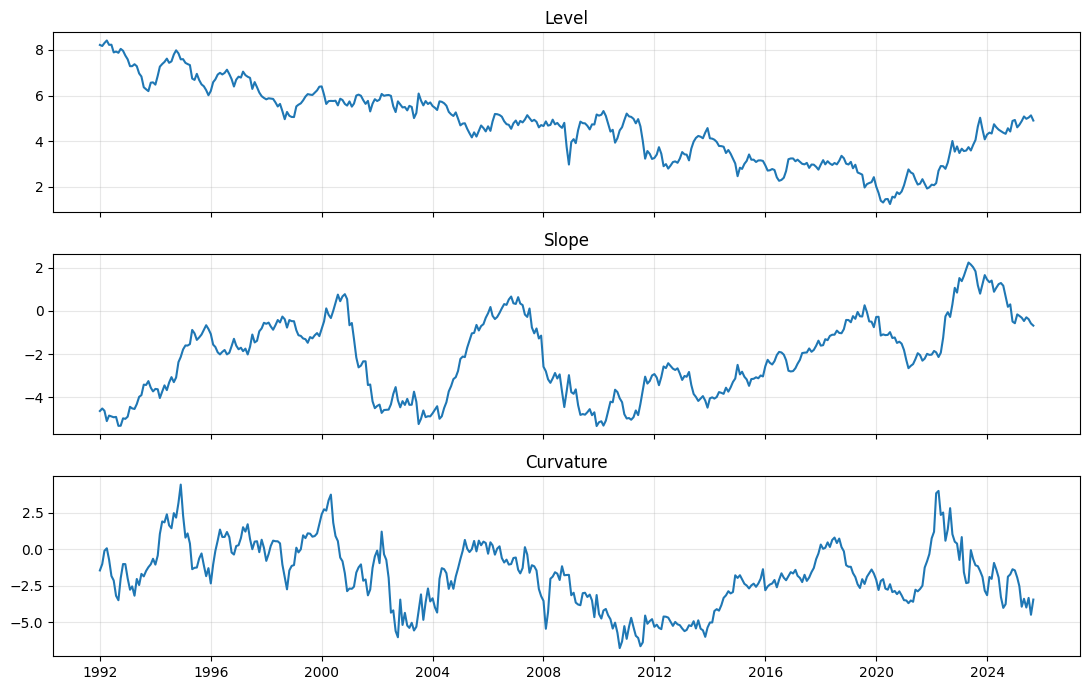

In [17]:
def fit_factors(yield_row):
    beta, *_ = np.linalg.lstsq(DESIGN, yield_row.values, rcond=None)
    return beta

factors = Y.apply(fit_factors, axis=1, result_type="expand")
factors.columns = ["Level", "Slope", "Curvature"]

#reconstruction quality: how well 3 factors reproduce 6 yields
recon = factors.values @ DESIGN.T
fit_rmse = np.sqrt(((recon - Y.values) ** 2).mean())
print(f"In-sample curve reconstruction RMSE (3 factors -> 6 yields): {fit_rmse:.4f}")
print("\nFactor summary:")
print(factors.describe().loc[["mean","std","min","max"]].round(3))

fig, ax = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for a, c in zip(ax, factors.columns):
    a.plot(factors.index, factors[c]); a.set_title(c); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [18]:
dns_models = ["DNS_AR", "DNS_VAR"]
dns_preds = {m: pd.DataFrame(index=test_dates, columns=yield_col, dtype=float) for m in dns_models}

for t in range(split, len(Y)):
    date = Y.index[t]
    hist_factors = factors.iloc[:t]          # factors known up to t

    #DNS-AR: AR(1) per factor
    try:
        f_ar = [ARIMA(hist_factors[c], order=(1,0,0)).fit().forecast(1).iloc[0]
                for c in factors.columns]
        dns_preds["DNS_AR"].loc[date] = np.array(f_ar) @ DESIGN.T
    except Exception:
        dns_preds["DNS_AR"].loc[date] = Y.iloc[t-1].values     # RW fallback

    #DNS-VAR: VAR(1) on the 3 factors
    try:
        vr = VAR(hist_factors).fit(1)
        f_var = vr.forecast(hist_factors.values[-1:], steps=1)[0]
        dns_preds["DNS_VAR"].loc[date] = f_var @ DESIGN.T
    except Exception:
        dns_preds["DNS_VAR"].loc[date] = Y.iloc[t-1].values

actual = Y.loc[test_dates]
print("DNS walk-forward complete:", dns_models)

DNS walk-forward complete: ['DNS_AR', 'DNS_VAR']


In [19]:
save_dns_preds = pd.concat({m: dns_preds[m] for m in dns_models}, axis=1)
save_dns_preds.columns = [f"{m}__{c}" for m, c in save_dns_preds.columns]
save_dns_preds.to_parquet(PROC / "dns_predictions.parquet")
print("Saved:", PROC / "dns_predictions.parquet")

Saved: D:\yield_curve_forecast\data\processed\dns_predictions.parquet


Loaded all forecasts for a combined comparison.
RMSE (lower = better)

         RandomWalk  DNS_AR  DNS_VAR  ARIMA  ARIMAX  VAR_diff
DGS3MO       0.2288  0.1910   0.1568 0.1730  0.1993    0.2061
DGS1         0.2570  0.3407   0.3119 0.2282  0.2290    0.2400
DGS2         0.3068  0.3285   0.3164 0.3030  0.3092    0.3026
DGS5         0.3080  0.3043   0.3071 0.3170  0.3270    0.3144
DGS10        0.2805  0.2647   0.2662 0.2901  0.3044    0.2877
DGS30        0.2486  0.2855   0.2826 0.2539  0.2654    0.2546
AVERAGE      0.2716  0.2858   0.2735 0.2609  0.2724    0.2675


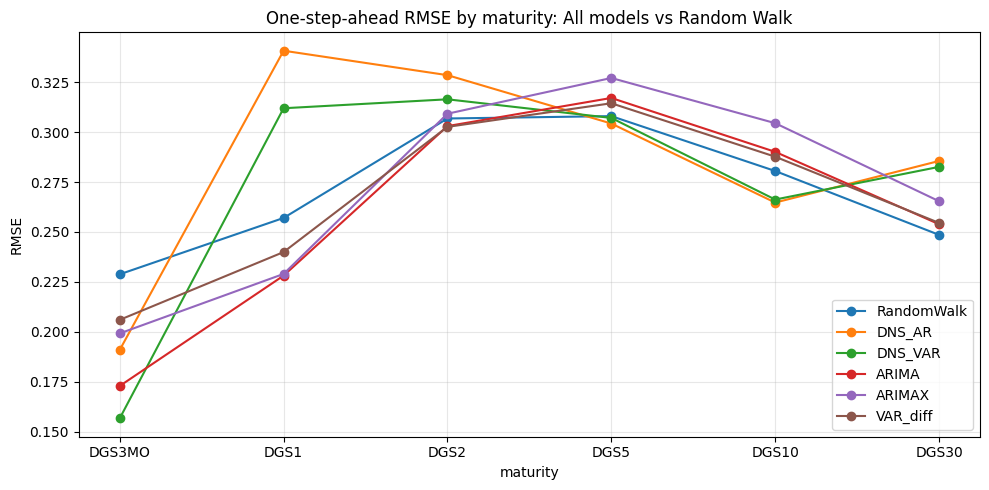

In [20]:
def rmse(a,f): return np.sqrt(np.nanmean((a-f)**2))
def mae(a,f):  return np.nanmean(np.abs(a-f))

# random-walk baseline (last value), always available here
rw = pd.DataFrame({c: Y[c].shift(1).loc[test_dates] for c in yield_col})

all_preds = {"RandomWalk": rw, **dns_preds}

p3 = PROC / "predictions.parquet"
if p3.exists():
    saved = pd.read_parquet(p3)
    saved_models = sorted({col.split("__")[0] for col in saved.columns})
    for m in saved_models:
        model_cols = {col: col.split("__")[1] for col in saved.columns if col.startswith(f"{m}__")}
        all_preds[m] = saved[list(model_cols.keys())].rename(columns=model_cols).reindex(test_dates)
    print("Loaded all forecasts for a combined comparison.")

rmse_tbl = pd.DataFrame({m: [rmse(actual[c], all_preds[m][c]) for c in yield_col]
                         for m in all_preds}, index=yield_col)
rmse_tbl.loc["AVERAGE"] = rmse_tbl.mean()
print("RMSE (lower = better)\n")
print(rmse_tbl)

ax = rmse_tbl.drop("AVERAGE").plot(marker="o", figsize=(10,5))
ax.set_title("One-step-ahead RMSE by maturity: All models vs Random Walk")
ax.set_xlabel("maturity"); ax.set_ylabel("RMSE"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [21]:
best_per_maturity = rmse_tbl.drop(columns="RandomWalk").min(axis=1)
pct_reduction = (rmse_tbl["RandomWalk"] - best_per_maturity) / rmse_tbl["RandomWalk"] * 100
print(pct_reduction.round(1))

DGS3MO    31.5000
DGS1      11.2000
DGS2       1.4000
DGS5       1.2000
DGS10      5.6000
DGS30     -2.1000
AVERAGE    4.0000
dtype: float64


In [22]:
def diebold_mariano(e1, e2, h=1):
    e1, e2 = np.asarray(e1,float), np.asarray(e2,float)
    d = (e1**2 - e2**2); d = d[~np.isnan(d)]
    T = len(d); dbar = d.mean()
    var = np.sum((d-dbar)**2)/T
    for k in range(1,h):
        var += 2*np.sum((d[k:]-dbar)*(d[:-k]-dbar))/T
    dm = dbar/np.sqrt(var/T)
    dm *= np.sqrt((T+1-2*h+h*(h-1)/T)/T)
    return dm, 2*stats.t.cdf(-abs(dm), df=T-1)

rows = []
for m in dns_models:
    for c in yield_col:
        eM = (actual[c]-dns_preds[m][c]).values
        eR = (actual[c]-rw[c]).values
        dm, p = diebold_mariano(eM, eR)
        rows.append({"model": m, "maturity": c, "DM_vs_RW": dm, "p_value": p,
                     "better": m if dm<0 else "RandomWalk", "sig_5%": p<0.05})
dm_tbl = pd.DataFrame(rows)
for m in dns_models:
    print(f"\n    {m} vs RandomWalk    ")
    print(dm_tbl[dm_tbl.model==m][["maturity","DM_vs_RW","p_value","better","sig_5%"]].to_string(index=False))


    DNS_AR vs RandomWalk    
maturity  DM_vs_RW  p_value     better  sig_5%
  DGS3MO   -2.8271   0.0064     DNS_AR    True
    DGS1    3.5895   0.0007 RandomWalk    True
    DGS2    1.6132   0.1120 RandomWalk   False
    DGS5   -0.3574   0.7220     DNS_AR   False
   DGS10   -1.4377   0.1558     DNS_AR   False
   DGS30    2.9894   0.0041 RandomWalk    True

    DNS_VAR vs RandomWalk    
maturity  DM_vs_RW  p_value     better  sig_5%
  DGS3MO   -2.3209   0.0238    DNS_VAR    True
    DGS1    2.4649   0.0166 RandomWalk    True
    DGS2    0.9726   0.3347 RandomWalk   False
    DGS5   -0.0650   0.9484    DNS_VAR   False
   DGS10   -1.0818   0.2837    DNS_VAR   False
   DGS30    3.0650   0.0033 RandomWalk    True


In [23]:
from statsmodels.stats.multitest import multipletests

def add_multiple_testing_correction(dm_df, p_col="p_value", method="fdr_bh"):
    dm_df = dm_df.copy()
    reject, p_adj, _, _ = multipletests(dm_df[p_col], alpha=0.05, method=method)
    dm_df["p_adj"] = p_adj
    dm_df["significant_adj_5%"] = reject
    return dm_df

dm_tbl_adj = add_multiple_testing_correction(dm_tbl)
print(dm_tbl_adj[["model","maturity","p_value","p_adj","sig_5%","significant_adj_5%"]]
      .to_string(index=False))

  model maturity  p_value  p_adj  sig_5%  significant_adj_5%
 DNS_AR   DGS3MO   0.0064 0.0192    True                True
 DNS_AR     DGS1   0.0007 0.0081    True                True
 DNS_AR     DGS2   0.1120 0.1921   False               False
 DNS_AR     DGS5   0.7220 0.7877   False               False
 DNS_AR    DGS10   0.1558 0.2337   False               False
 DNS_AR    DGS30   0.0041 0.0163    True                True
DNS_VAR   DGS3MO   0.0238 0.0475    True                True
DNS_VAR     DGS1   0.0166 0.0399    True                True
DNS_VAR     DGS2   0.3347 0.4017   False               False
DNS_VAR     DGS5   0.9484 0.9484   False               False
DNS_VAR    DGS10   0.2837 0.3783   False               False
DNS_VAR    DGS30   0.0033 0.0163    True                True


In [24]:
#DM tests: DNS vs ARIMA
p3_path = PROC / "predictions.parquet"

if p3_path.exists():
    p3_raw = pd.read_parquet(p3_path)
    p3_preds = {
        m: p3_raw[[f"{m}__{c}" for c in yield_col]]
             .rename(columns=lambda x: x.split("__")[1])
             .reindex(test_dates)
        for m in ["ARIMA"]
    }

    rows = []
    for dns_m in dns_models:
        for p3_m in ["ARIMA"]:
            for c in yield_col:
                eD = (actual[c] - dns_preds[dns_m][c]).values
                eP = (actual[c] - p3_preds[p3_m][c]).values
                dm, p = diebold_mariano(eD, eP)
                rows.append({"comparison": f"{dns_m} vs {p3_m}", "maturity": c,
                             "DM": dm, "p_value": p,
                             "better": dns_m if dm < 0 else p3_m,
                             "significant_5%": p < 0.05})

    dns_vs_previous = pd.DataFrame(rows)
    for comp in dns_vs_previous["comparison"].unique():
        sub = dns_vs_previous[dns_vs_previous["comparison"] == comp]
        print(f"\n    {comp}    ")
        print(sub[["maturity","DM","p_value","better","significant_5%"]].to_string(index=False))
else:
    print("Run the prerequisite 'persist forecasts' cell in 04_forecasting.ipynb first.")


    DNS_AR vs ARIMA    
maturity      DM  p_value better  significant_5%
  DGS3MO  1.1342   0.2613  ARIMA           False
    DGS1  3.1742   0.0024  ARIMA            True
    DGS2  1.0913   0.2796  ARIMA           False
    DGS5 -1.0422   0.3016 DNS_AR           False
   DGS10 -2.0666   0.0432 DNS_AR            True
   DGS30  2.2306   0.0295  ARIMA            True

    DNS_VAR vs ARIMA    
maturity      DM  p_value  better  significant_5%
  DGS3MO -0.8749   0.3852 DNS_VAR           False
    DGS1  2.9509   0.0045   ARIMA            True
    DGS2  0.8226   0.4140   ARIMA           False
    DGS5 -0.7293   0.4687 DNS_VAR           False
   DGS10 -1.8027   0.0765 DNS_VAR           False
   DGS30  2.2013   0.0316   ARIMA            True


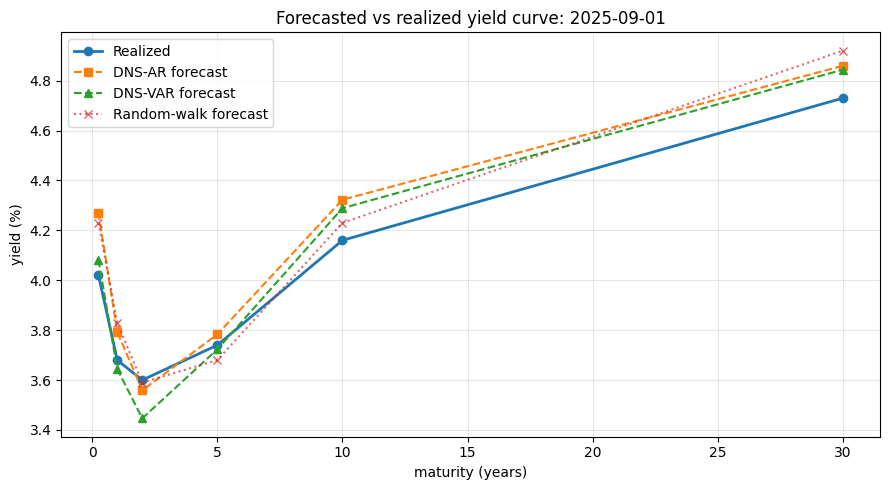

In [25]:
sample = test_dates[-1]
plt.figure(figsize=(9,5))
plt.plot(maturities, actual.loc[sample].values, "o-", label="Realized", lw=2)
plt.plot(maturities, dns_preds["DNS_AR"].loc[sample].values, "s--", label="DNS-AR forecast")
plt.plot(maturities, dns_preds["DNS_VAR"].loc[sample].values, "^--", label="DNS-VAR forecast")
plt.plot(maturities, rw.loc[sample].values, "x:", label="Random-walk forecast", alpha=0.7)
plt.title(f"Forecasted vs realized yield curve: {sample.date()}")
plt.xlabel("maturity (years)"); plt.ylabel("yield (%)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [26]:
#Does DNS's advantage show up at longer horizons?

HORIZONS = [1, 3, 6, 12]   # months ahead

def multi_horizon_walkforward(h):
    idx = range(split, len(Y) - h + 1)   
    dates_h = Y.index[list(idx)]
    rw_h  = pd.DataFrame(index=dates_h, columns=yield_col, dtype=float)
    ar_h  = pd.DataFrame(index=dates_h, columns=yield_col, dtype=float)
    var_h = pd.DataFrame(index=dates_h, columns=yield_col, dtype=float)
    actual_h = pd.DataFrame(index=dates_h, columns=yield_col, dtype=float)

    for t in idx:
        date = Y.index[t]
        target_date = Y.index[t + h - 1]
        hist_factors = factors.iloc[:t]

        actual_h.loc[date] = Y.loc[target_date].values
        rw_h.loc[date] = Y.iloc[t - 1].values

        # DNS-AR: iterating the AR(1) forward h steps per factor
        try:
            f_h = []
            for c in factors.columns:
                fit = ARIMA(hist_factors[c], order=(1, 0, 0)).fit()
                f_h.append(fit.forecast(h).iloc[-1])   # h-step-ahead value
            ar_h.loc[date] = np.array(f_h) @ DESIGN.T
        except Exception:
            ar_h.loc[date] = Y.iloc[t - 1].values

        # DNS-VAR: iterating the VAR(1) forward h steps jointly
        try:
            vr = VAR(hist_factors).fit(1)
            f_path = vr.forecast(hist_factors.values[-1:], steps=h)
            var_h.loc[date] = f_path[-1] @ DESIGN.T
        except Exception:
            var_h.loc[date] = Y.iloc[t - 1].values

    return actual_h, rw_h, ar_h, var_h

results = {}
for h in HORIZONS:
    actual_h, rw_h, ar_h, var_h = multi_horizon_walkforward(h)
    rmse_row = {
        "RandomWalk": [rmse(actual_h[c], rw_h[c]) for c in yield_col],
        "DNS_AR":     [rmse(actual_h[c], ar_h[c]) for c in yield_col],
        "DNS_VAR":    [rmse(actual_h[c], var_h[c]) for c in yield_col],
    }
    results[h] = pd.DataFrame(rmse_row, index=yield_col)
    print(f"\n    h={h} month(s) ahead    ")
    print(results[h])

# Does DNS's RMSE *advantage* over RW grow with horizon? (negative = DNS better)
gap = pd.DataFrame({
    h: results[h]["DNS_VAR"] - results[h]["RandomWalk"] for h in HORIZONS
})
print("\nDNS_VAR minus RandomWalk RMSE, by horizon (negative = DNS wins):")
print(gap)


    h=1 month(s) ahead    
        RandomWalk  DNS_AR  DNS_VAR
DGS3MO      0.2288  0.1910   0.1568
DGS1        0.2570  0.3407   0.3119
DGS2        0.3068  0.3285   0.3164
DGS5        0.3080  0.3043   0.3071
DGS10       0.2805  0.2647   0.2662
DGS30       0.2486  0.2855   0.2826

    h=3 month(s) ahead    
        RandomWalk  DNS_AR  DNS_VAR
DGS3MO      0.6094  0.5754   0.4309
DGS1        0.6066  0.7138   0.6081
DGS2        0.6202  0.6622   0.6147
DGS5        0.5655  0.5539   0.5544
DGS10       0.5182  0.4775   0.4789
DGS30       0.4595  0.4970   0.4910

    h=6 month(s) ahead    
        RandomWalk  DNS_AR  DNS_VAR
DGS3MO      1.1717  1.1532   0.8281
DGS1        1.0890  1.2172   0.9847
DGS2        0.9755  1.0527   0.9256
DGS5        0.7786  0.7698   0.7476
DGS10       0.6788  0.6232   0.6145
DGS30       0.6108  0.6381   0.6245

    h=12 month(s) ahead    
        RandomWalk  DNS_AR  DNS_VAR
DGS3MO      2.1931  2.1682   1.7118
DGS1        2.0447  2.1314   1.8628
DGS2        1.7856  1.8

In [27]:
dm_rows = []
for h in HORIZONS:
    actual_h, rw_h, ar_h, var_h = multi_horizon_walkforward(h)
    for c in yield_col:
        eD = (actual_h[c] - var_h[c]).values
        eR = (actual_h[c] - rw_h[c]).values
        dm, p = diebold_mariano(eD, eR, h=h)   
        dm_rows.append({"h": h, "maturity": c, "DM": dm, "p_value": p, "sig_5%": p < 0.05})

dm_horizon_tbl = pd.DataFrame(dm_rows)
print(dm_horizon_tbl.pivot(index="maturity", columns="h", values="p_value"))

h            1      3      6      12
maturity                            
DGS1     0.0166 0.9824 0.5302 0.2331
DGS10    0.2837 0.1108 0.1229 0.1377
DGS2     0.3347 0.8574 0.5099 0.3036
DGS30    0.0033 0.0421 0.0886 0.0638
DGS3MO   0.0238 0.2404 0.3391 0.2446
DGS5     0.9484 0.6109 0.4552 0.1384


In [28]:
#Setup: identify ARIMA/VAR

train_init = Y.iloc[:split]

def _best_arima_order(series, p_range=(0,1,2), q_range=(0,1,2)):
    best_aic, best_order = np.inf, (0,1,0)
    for p in p_range:
        for q in q_range:
            try:
                aic = ARIMA(series, order=(p,1,q)).fit().aic
                if aic < best_aic:
                    best_aic, best_order = aic, (p,1,q)
            except Exception:
                continue
    return best_order

arima_orders_h = {c: _best_arima_order(train_init[c]) for c in yield_col}
var_lag_h   = max(VAR(train_init.diff().dropna()).select_order(maxlags=6).aic, 1)
COINT_RANK_h = 4
print("ARIMA orders:", arima_orders_h, "\nVAR lag:", var_lag_h)

ARIMA orders: {'DGS3MO': (1, 1, 1), 'DGS1': (2, 1, 0), 'DGS2': (1, 1, 0), 'DGS5': (1, 1, 1), 'DGS10': (1, 1, 1), 'DGS30': (1, 1, 1)} 
VAR lag: 2


In [29]:
def multi_horizon_walkforward_full(h):
    idx = range(split, len(Y) - h + 1)
    dates_h = Y.index[list(idx)]
    frames = {m: pd.DataFrame(index=dates_h, columns=yield_col, dtype=float)
              for m in ["RandomWalk", "ARIMA", "VAR_diff", "DNS_AR", "DNS_VAR"]}
    actual_h = pd.DataFrame(index=dates_h, columns=yield_col, dtype=float)

    for t in idx:
        date = Y.index[t]
        target_date = Y.index[t + h - 1]
        hist = Y.iloc[:t]
        hist_factors = factors.iloc[:t]
        last_level = hist.iloc[-1]
        actual_h.loc[date] = Y.loc[target_date].values

        frames["RandomWalk"].loc[date] = last_level.values

        for c in yield_col:
            try:
                f = ARIMA(hist[c], order=arima_orders_h[c]).fit().forecast(h).iloc[-1]
            except Exception:
                f = last_level[c]
            frames["ARIMA"].loc[date, c] = f

        try:
            dh = hist.diff().dropna()
            vr = VAR(dh).fit(var_lag_h)
            path = vr.forecast(dh.values[-var_lag_h:], steps=h)
            frames["VAR_diff"].loc[date] = last_level.values + path.sum(axis=0)
        except Exception:
            frames["VAR_diff"].loc[date] = last_level.values

        try:
            f_ar = [ARIMA(hist_factors[c], order=(1,0,0)).fit().forecast(h).iloc[-1]
                    for c in factors.columns]
            frames["DNS_AR"].loc[date] = np.array(f_ar) @ DESIGN.T
        except Exception:
            frames["DNS_AR"].loc[date] = last_level.values

        try:
            vr = VAR(hist_factors).fit(1)
            f_path = vr.forecast(hist_factors.values[-1:], steps=h)
            frames["DNS_VAR"].loc[date] = f_path[-1] @ DESIGN.T
        except Exception:
            frames["DNS_VAR"].loc[date] = last_level.values

    return actual_h, frames

full_results = {h: multi_horizon_walkforward_full(h) for h in HORIZONS}

dm_rows_full = []
for h in HORIZONS:
    actual_h, frames = full_results[h]
    for comp_model in ["ARIMA", "VAR_diff"]:
        for c in yield_col:
            eD = (actual_h[c] - frames["DNS_VAR"][c]).values
            eC = (actual_h[c] - frames[comp_model][c]).values
            dm, p = diebold_mariano(eD, eC, h=h)
            dm_rows_full.append({"h": h, "comparison": f"DNS_VAR vs {comp_model}",
                                  "maturity": c, "DM": dm, "p_value": p, "sig_5%": p < 0.05})

dm_horizon_full_tbl = pd.DataFrame(dm_rows_full)
for comp in dm_horizon_full_tbl["comparison"].unique():
    print(f"\n     {comp}     ")
    print(dm_horizon_full_tbl[dm_horizon_full_tbl.comparison == comp]
          .pivot(index="maturity", columns="h", values="p_value"))


     DNS_VAR vs ARIMA     
h            1      3      6      12
maturity                            
DGS1     0.0042 0.2706 0.9227 0.3646
DGS10    0.0913 0.0657 0.0738 0.1197
DGS2     0.4756 0.8917 0.4299 0.3222
DGS30    0.0213 0.0720 0.1936 0.0569
DGS3MO   0.3497 0.7999 0.5521 0.1804
DGS5     0.5172 0.4866 0.3873 0.0620

     DNS_VAR vs VAR_diff     
h            1      3      6      12
maturity                            
DGS1     0.0169 0.3338 0.6112 0.2019
DGS10    0.0878 0.0404 0.0035 0.1089
DGS2     0.5209 0.8960 0.0277 0.2441
DGS30    0.0630 0.2821 0.0000 0.0466
DGS3MO   0.0287 0.4559 0.3815 0.2375
DGS5     0.5183 0.1993 0.0004 0.2324
